In [36]:
import pickle
from PyFingerprint.fingerprint import get_fingerprint

with open("new_model.pkl", 'rb') as file:
    model = pickle.load(file)

with open("new_removed_cols.pkl", 'rb') as file:
    cols_2_remove = pickle.load(file)

In [37]:
import numpy as np

def featurize(smiles):
    r = []
    j = ['topological-torsion', 'hybridization', 'morgan', 'extended', 'fp2']
    for t in j:
        finger = list(get_fingerprint(smiles, t).to_numpy())
        if t == 'rdk-descriptor':
            if finger[42] is not None and finger[42] > np.finfo(np.float32).max:
                finger[42] = np.finfo(np.float32).max
        r += finger
    return r

In [38]:
import pandas as pd
import os


#returns pandas df of all features
def get_X(smiles):
    data = {'SMILES': smiles}

    labels = labels = [f'fp_{i}' for i in range(7168)]
    
    df = pd.DataFrame(data)
    df['features'] = df['SMILES'].apply(featurize)
    df = df.dropna(subset=['features'])
    features_df = pd.DataFrame(df['features'].tolist(), columns=labels)
    print(features_df.shape)
    #cols_2_remove_existing = [col for col in cols_2_remove if col in features_df.columns]
    #features_df = features_df.drop(columns=cols_2_remove_existing)
    features_df = features_df.drop(columns=cols_2_remove)
    print(features_df.shape)
    return features_df

In [39]:
def is_outlier(value):
    if(value > 5000):
        return value
    return None

In [40]:
df = pd.read_csv("ic50_mols.csv")
df = df.dropna(subset=["IC50 (nM)"])
df = df[pd.to_numeric(df['IC50 (nM)'], errors='coerce').notna()]
df['IC50 (nM)'] = df['IC50 (nM)'].astype(float)

In [41]:
#wddf['IC50 (nM)'] = df['IC50 (nM)'].apply(is_outlier)
df = df.dropna(subset=['IC50 (nM)'])
df = df[pd.to_numeric(df['IC50 (nM)'], errors='coerce').notna()]
print(df.shape)
print(df.head)

(3094, 2)
<bound method NDFrame.head of                                           Ligand SMILES    IC50 (nM)
138   CCCCc1nn(-c2cc(NC(=O)CC)ccc2Cl)c(=O)n1Cc1ccc(c...        0.043
139   CCCCc1nn(-c2cc(NC(=O)CC)ccc2Cl)c(=O)n1Cc1ccc(c...        0.043
140   CCc1nc2c(C)cc(C)nc2n1Cc1ccc(cc1)-c1ccccc1S(=O)...        0.050
141   CCCCc1nn(-c2cc(NC(C)=O)ccc2Cl)c(=O)n1Cc1ccc(cc...        0.052
142   CCCCc1nn(-c2cc(NC(C)=O)ccc2Cl)c(=O)n1Cc1ccc(cc...        0.052
...                                                 ...          ...
3700                [O-][N+](=O)c1ccccc1COC(=O)c1ccccc1   723000.000
3701                     CC(=O)Nc1ccccc1COC(=O)c1ccccc1   850000.000
3702       CCCCc1nc(Cl)c(CO)n1Cc1ccc(cc1)-n1cccc1C(O)=O   870000.000
3704              [O-][N+](=O)c1ccc(COC(=O)c2ccccc2)cc1  1080000.000
3705  COc1ccc2CN(C(Cc2c1OCc1ccccc1)C(O)=O)C(=O)C(c1c...  2900000.000

[3094 rows x 2 columns]>


In [42]:
df['IC50_nM_float'] = pd.to_numeric(df['IC50 (nM)'], errors='coerce')
df = df.dropna(subset=['IC50_nM_float'])
df['IC50 (M)'] = df['IC50_nM_float'] / 1e9
df['pIC50'] = -np.log10(df['IC50 (M)'])
smiles = df['Ligand SMILES'].tolist()

In [43]:
y_hat = model.predict(get_X(smiles).to_numpy())
y_actual = df['pIC50'].tolist()

(3094, 7168)
(3094, 6336)


c:\Users\yhtru\anaconda3\envs\pyfingerprint\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


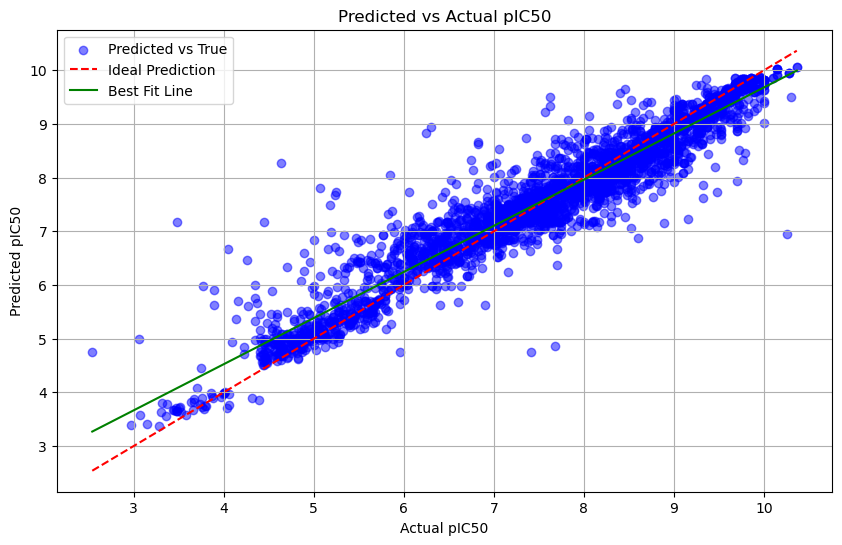

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_actual, y_hat, label='Predicted vs True', color='blue', alpha=0.5)

# Line with slope 1 going through (0, 0)
min_val = min(min(y_actual), min(y_hat))
max_val = max(max(y_actual), max(y_hat))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Prediction')

# Line of best fit
slope, intercept = np.polyfit(y_actual, y_hat, 1)
best_fit_line = slope * np.array([min_val, max_val]) + intercept
plt.plot([min_val, max_val], best_fit_line, color='green', linestyle='-', label='Best Fit Line')

plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title('Predicted vs Actual pIC50')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
from sklearn.metrics import r2_score

print(r2_score(y_actual, y_hat))
print(f"slope: {slope}")
print(f"intercept {intercept}")

0.9063873225259323


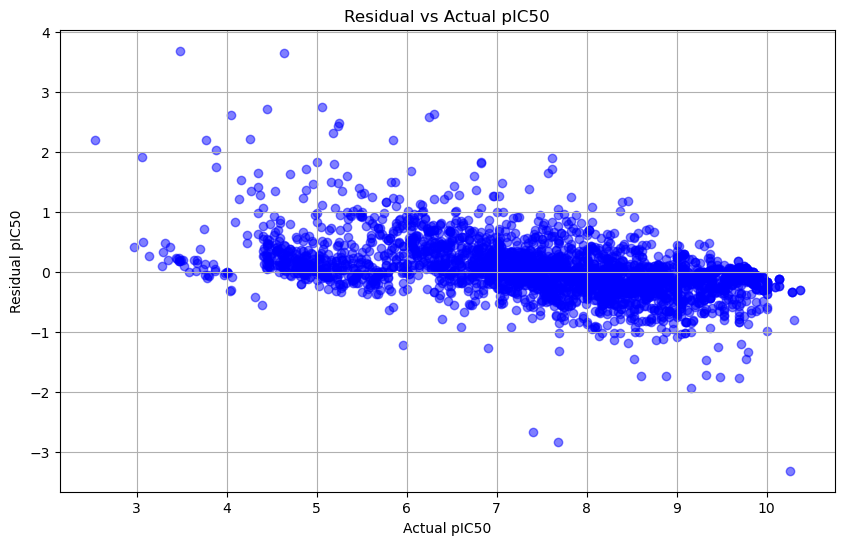

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(y_actual, y_hat-y_actual, label='residulss', color='blue', alpha=0.5)

plt.xlabel('Actual pIC50')
plt.ylabel('Residual pIC50')
plt.title('Residual vs Actual pIC50')
plt.grid(True)
plt.show()